# LemoScan AI | Duplicate review and proposed grouping

**Analysis only ? no dataset changes ? no new split ? no model training**

This notebook builds on `00_dataset_audit.ipynb`. It combines independent types of visual evidence to prioritize review and propose groups, not to establish biological specimen identity. The metrics themselves are correlated and are not calibrated probabilities.

**Outputs:** pair evidence, proposed visual clusters, candidate capture sequences, a one-row-per-image manifest, contact sheets, and a machine-generated summary in `reports/dataset_audit/`.

Run in order. Requirements: Python, NumPy, Pandas, Pillow, Matplotlib, IPython. No automatic installation. SHA-256 checks before and after execution verify that the dataset is unchanged. Existing audit reports are inputs and are never overwritten.


## 1. Configuration and input validation
Root discovery supports a kernel started from the project or a child directory. Set the override otherwise. Missing, changed, added, or inconsistent images stop analysis rather than silently reusing stale evidence. Input hashes record provenance.


In [ ]:
from pathlib import Path
from collections import defaultdict
from itertools import combinations
from functools import lru_cache
import hashlib
import importlib.metadata as metadata
import json
import platform
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT_OVERRIDE = None  # Example: Path(r"E:\LemoScan-AI")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
SPLITS = ("train", "val", "test")
EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff", ".gif"}
MAX_IMAGES_PER_SHEET = 8
MAX_STRONG_SHEETS = 3
MAX_LARGE_SHEETS = 2
MAX_UNCERTAIN_SHEETS = 3
SEQUENCE_MAX_GAP = 1


def resolve_root(override=None):
    candidates = [Path(override).expanduser().resolve()] if override else [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for path in candidates:
        if (path / "dataset").is_dir() and (path / "utils/model_loader.py").is_file():
            return path
    raise FileNotFoundError("Set PROJECT_ROOT_OVERRIDE to the LemoScan-AI project root.")


ROOT = resolve_root(PROJECT_ROOT_OVERRIDE)
DATASET = (ROOT / "dataset").resolve()
REPORTS = ROOT / "reports/dataset_audit"
assert not REPORTS.resolve().is_relative_to(DATASET)
INPUT_NAMES = ["image_inventory.csv", "exact_duplicates.csv", "near_duplicate_candidates.csv",
               "filename_patterns.csv", "capture_group_candidates.csv"]
missing = [name for name in INPUT_NAMES if not (REPORTS / name).is_file()]
if missing:
    raise FileNotFoundError(f"Run notebook 00 first. Missing reports: {missing}")
inputs = {name: pd.read_csv(REPORTS / name, keep_default_na=False) for name in INPUT_NAMES}
inventory = inputs["image_inventory.csv"].sort_values("filepath").reset_index(drop=True)
exact_input = inputs["exact_duplicates.csv"]
near_input = inputs["near_duplicate_candidates.csv"]
filename_input = inputs["filename_patterns.csv"]
capture_input = inputs["capture_group_candidates.csv"]
assert inventory["filepath"].is_unique and len(inventory) > 0
assert set(inventory["split"]).issubset(SPLITS)
records = inventory.set_index("filepath").to_dict("index")
paths = sorted(records)
versions = {name: metadata.version(name) for name in ("numpy", "pandas", "Pillow", "matplotlib", "ipython")}
print("Project:", ROOT)
display(pd.Series(versions, name="version").to_frame())


Project: E:\LemoScan-AI


,version
numpy,2.3.4
pandas,2.3.3
Pillow,11.3.0
matplotlib,3.10.7
ipython,9.6.0


In [ ]:
def digest_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def dataset_path(relative):
    path = (ROOT / relative).resolve()
    if not path.is_relative_to(DATASET) or not path.is_file():
        raise ValueError(f"Missing or unsafe dataset reference: {relative}")
    return path


def dataset_snapshot():
    return {p.relative_to(ROOT).as_posix(): {"sha256": digest_file(p), "size": p.stat().st_size,
                                           "mtime_ns": p.stat().st_mtime_ns}
            for p in sorted(DATASET.rglob("*")) if p.is_file()}


all_references = set(paths)
for frame, columns in [(exact_input, ["filepath"]), (near_input, ["filepath_a", "filepath_b"]),
                       (filename_input, ["filepath"])]:
    for column in columns:
        all_references.update(frame[column])
for members in capture_input["filepaths"]:
    all_references.update(json.loads(members))
unknown = all_references - set(paths)
if unknown:
    raise ValueError(f"References absent from inventory: {sorted(unknown)[:5]}")
for path in sorted(all_references):
    dataset_path(path)
BEFORE = dataset_snapshot()
current_images = {p for p in BEFORE if Path(p).suffix.lower() in EXTENSIONS}
assert current_images == set(paths), "Inventory membership is stale. Rerun audit 00."
stale = [p for p in paths if BEFORE[p]["sha256"] != records[p]["sha256"]]
if stale:
    raise ValueError(f"Images changed since audit 00: {stale[:5]}")
assert filename_input["filepath"].is_unique and set(filename_input["filepath"]) == set(paths)
for row in near_input.itertuples(index=False):
    for side in ("a", "b"):
        rec = records[getattr(row, f"filepath_{side}")]
        assert rec["split"] == getattr(row, f"split_{side}")
        assert rec["class"] == getattr(row, f"class_{side}")
for row in exact_input.to_dict("records"):
    assert row["sha256"] == records[row["filepath"]]["sha256"]
INPUT_HASHES = {name: digest_file(REPORTS / name) for name in INPUT_NAMES}
print(f"Validated {len(paths):,} unchanged images and references in five audit reports.")


Validated 2,050 unchanged images and references in five audit reports.


## 2. Scope and conservative evidence categories
The original pool is cross-split and dHash-screened: this is **not an exhaustive search**. Exact pairs are restored from the inventory and checked against the exact report. To study local sequences, same-class/date pairs with neighboring numbers (gap ?1, including equal numbers) are added, also within splits. Secondary features are cached per image.

| Category | Rule, applied in order | Interpretation |
|---|---|---|
| A ? exact byte duplicate | Identical SHA-256 | Confirmed bytes |
| B ? very-high-confidence visual duplicate | pHash ?2/63, RGB MAE ?0.015, histogram intersection ?0.98 | Strict visual candidate, not proof |
| C ? probable near duplicate | pHash ?6, MAE ?0.04, histogram ?0.94 | Multiple agreeing signals; review |
| D ? visually similar but uncertain | pHash ?12 and (MAE ?0.10 or histogram ?0.90) | Partial agreement |
| E ? weak candidate / likely false positive | Otherwise | Weak corroboration |

B requires small differences on all three metrics; C relaxes them. These are heuristic thresholds, not calibrated guarantees. MAE 0.015 corresponds to about 3.8/255 average channel difference. No registration or rotation/crop search is performed. Resizing may hide detail. Only A/B edges form proposed visual groups; filename adjacency alone never creates a visual group.


In [ ]:
CATEGORY_LABELS = {"A": "exact byte duplicate", "B": "very-high-confidence visual duplicate",
                   "C": "probable near duplicate", "D": "visually similar but uncertain",
                   "E": "weak candidate / likely false positive"}
THRESHOLDS = {"B": {"phash": 2, "mae": 0.015, "color": 0.98},
              "C": {"phash": 6, "mae": 0.04, "color": 0.94},
              "D": {"phash": 12, "mae": 0.10, "color": 0.90}}
STRONG_CATEGORIES = {"A", "B"}
CAPTURE_CATEGORIES = {"A", "B", "C"}


def pair_key(first, second):
    return tuple(sorted((first, second)))


pair_sources = defaultdict(set)
existing_dhash = {}
for row in near_input.itertuples(index=False):
    key = pair_key(row.filepath_a, row.filepath_b)
    assert key not in existing_dhash, "Duplicate original pair"
    existing_dhash[key] = int(row.hamming_distance)
    pair_sources[key].add("audit_near_candidate")
exact_groups = [sorted(group["filepath"]) for _, group in inventory.groupby("sha256", sort=True) if len(group) > 1]
assert {p for group in exact_groups for p in group} == set(exact_input["filepath"])
for group in exact_groups:
    for first, second in combinations(group, 2):
        pair_sources[pair_key(first, second)].add("exact_hash")
filename_records = filename_input.set_index("filepath").to_dict("index")
pattern_frame = filename_input.copy()
pattern_frame["image_number"] = pd.to_numeric(pattern_frame["image_number"], errors="coerce")
pattern_frame = pattern_frame.loc[pattern_frame["date_token"].ne("")].dropna(subset=["image_number"])
for _, group in pattern_frame.groupby(["class", "date_token"], sort=True):
    rows = group.sort_values(["image_number", "filepath"]).to_dict("records")
    for index, first in enumerate(rows):
        for second in rows[index + 1:]:
            if second["image_number"] - first["image_number"] > SEQUENCE_MAX_GAP:
                break
            pair_sources[pair_key(first["filepath"], second["filepath"])].add("filename_neighbor")
print(f"Original near pairs: {len(existing_dhash):,}; expanded unique pairs: {len(pair_sources):,}")
print(f"Prior broad capture groups: {len(capture_input)}; not automatically merged.")


Original near pairs: 476; expanded unique pairs: 2,229
Prior broad capture groups: 6; not automatically merged.


## 3. Secondary visual metrics
A NumPy orthonormal DCT-II transforms a 32?32 grayscale image. The top-left 8?8 block excludes DC, leaving **63** median-thresholded pHash bits. RGB MAE uses EXIF-oriented 64?64 images scaled to [0,1]. Color similarity averages normalized 32-bin histogram intersection across RGB channels (1 = identical distributions). Color ignores geometry and never establishes a strong match alone. Original dHash is retained and checked against recomputation.


In [ ]:
def dct_matrix(size):
    frequencies = np.arange(size)[:, None]
    positions = np.arange(size)[None, :]
    matrix = np.cos(np.pi * (2 * positions + 1) * frequencies / (2 * size))
    matrix *= np.sqrt(2 / size)
    matrix[0] /= np.sqrt(2)
    return matrix


DCT = dct_matrix(32)
assert np.allclose(DCT @ DCT.T, np.eye(32), atol=1e-12)


@lru_cache(maxsize=None)
def image_features(relative):
    with Image.open(dataset_path(relative)) as image:
        rgb = ImageOps.exif_transpose(image).convert("RGB")
        gray = rgb.convert("L")
        d_pixels = np.asarray(gray.resize((9, 8), Image.Resampling.LANCZOS))
        dhash = (d_pixels[:, 1:] > d_pixels[:, :-1]).ravel()
        gray32 = np.asarray(gray.resize((32, 32), Image.Resampling.LANCZOS), dtype=np.float64) / 255
        coefficients = (DCT @ gray32 @ DCT.T)[:8, :8].ravel()[1:]
        phash = coefficients > np.median(coefficients)
        pixels = np.asarray(rgb.resize((64, 64), Image.Resampling.LANCZOS), dtype=np.float32) / 255
    histograms = np.stack([np.histogram(pixels[..., channel], bins=32, range=(0, 1))[0] / (64 * 64) for channel in range(3)])
    return {"phash": phash, "phash_hex": f"{int(''.join('1' if bit else '0' for bit in phash), 2):016x}",
            "dhash": dhash, "pixels": pixels, "histograms": histograms}


def classify_similarity(exact, phash, mae, color):
    if exact: return "A"
    for category in ("B", "C"):
        limits = THRESHOLDS[category]
        if phash <= limits["phash"] and mae <= limits["mae"] and color >= limits["color"]:
            return category
    limits = THRESHOLDS["D"]
    if phash <= limits["phash"] and (mae <= limits["mae"] or color >= limits["color"]):
        return "D"
    return "E"


def compare_pair(first, second, sources):
    a, b = image_features(first), image_features(second)
    dhash_distance = int(np.count_nonzero(a["dhash"] != b["dhash"]))
    phash_distance = int(np.count_nonzero(a["phash"] != b["phash"]))
    mae = float(np.abs(a["pixels"] - b["pixels"]).mean())
    color = float(np.minimum(a["histograms"], b["histograms"]).sum(axis=1).mean())
    category = classify_similarity(records[first]["sha256"] == records[second]["sha256"], phash_distance, mae, color)
    row = {"filepath_a": first, "filepath_b": second, "sources": "|".join(sorted(sources)),
           "is_audit_near_candidate": "audit_near_candidate" in sources,
           "is_filename_neighbor": "filename_neighbor" in sources,
           "existing_dhash_distance": existing_dhash.get((first, second)),
           "dhash_distance": dhash_distance, "phash_a": a["phash_hex"], "phash_b": b["phash_hex"],
           "phash_distance": phash_distance, "normalized_pixel_mae": mae,
           "color_histogram_intersection": color, "category": category,
           "category_label": CATEGORY_LABELS[category],
           "review_status": "confirmed byte identity" if category == "A" else "requires human verification"}
    for side, path in (("a", first), ("b", second)):
        row.update({f"{field}_{side}": records[path][field] for field in ("filename", "class", "split", "sha256")})
    row["cross_split"] = row["split_a"] != row["split_b"]
    row["split_combination"] = "-".join(sorted({row["split_a"], row["split_b"]}, key=SPLITS.index))
    row["class_comparison"] = row["class_a"] if row["class_a"] == row["class_b"] else " <> ".join(sorted([row["class_a"], row["class_b"]]))
    fa, fb = filename_records[first], filename_records[second]
    na, nb = pd.to_numeric(fa["image_number"], errors="coerce"), pd.to_numeric(fb["image_number"], errors="coerce")
    row["same_class_date"] = row["class_a"] == row["class_b"] and bool(fa["date_token"]) and fa["date_token"] == fb["date_token"]
    row["filename_number_gap"] = abs(float(na) - float(nb)) if pd.notna(na) and pd.notna(nb) else np.nan
    return row


similarity = pd.DataFrame([compare_pair(first, second, sources) for (first, second), sources in sorted(pair_sources.items())])
original_mask = similarity["is_audit_near_candidate"]
assert (similarity.loc[original_mask, "dhash_distance"] == similarity.loc[original_mask, "existing_dhash_distance"]).all(), "dHash differs from audit 00."
similarity.to_csv(REPORTS / "similarity_review.csv", index=False)
display(similarity.groupby(["category", "category_label"]).size().rename("expanded_pairs").to_frame())
display(similarity.loc[original_mask].groupby(["category", "category_label"]).size().rename("original_near_pairs").to_frame())


,,expanded_pairs
category,category_label,
A,exact byte duplicate,3
B,very-high-confidence visual duplicate,15
C,probable near duplicate,515
D,visually similar but uncertain,421
E,weak candidate / likely false positive,1275


,,original_near_pairs
category,category_label,
B,very-high-confidence visual duplicate,7
C,probable near duplicate,263
D,visually similar but uncertain,187
E,weak candidate / likely false positive,19


## 4. Cross-split exposure analysis
Two scopes: **original audit pool plus exact pairs**, and **expanded pool** including neighboring filenames. All candidates measure broad review workload; A/B measure stricter evidence. Unique-image exposure is deduplicated by scope/tier, using the full split as denominator. Exposure is not a count of wrong predictions or a measure of accuracy inflation.


Expanded cross-split pairs by split combination and category:
Expanded cross-split pairs by disease class / cross-class comparison:
Original audit + exact pool, separately:


category,A,B,C,D,E
split_combination,,,,,
train-val,0,2,124,123,261
train-test,0,2,125,95,311
val-test,1,3,27,25,60


category,A,B,C,D,E
class_comparison,,,,,
Algal leaf spot,0,0,61,57,68
Algal leaf spot <> Greening,0,0,0,0,2
Algal leaf spot <> Healthy leaf,0,0,0,1,1
Black spot,0,0,35,46,91
Black spot <> Citrus canker,0,0,0,2,0
Citrus canker,0,0,41,34,118
Citrus canker <> Citrus pest,0,0,0,0,1
Citrus canker <> Greening,0,0,0,1,3
Citrus canker <> Healthy leaf,0,0,0,2,0


category,A,B,C,D,E
split_combination,,,,,
train-test,0,2,118,77,10
train-val,0,2,120,92,8
val-test,1,3,25,18,1


,scope,tier,split,unique_images,split_total,percentage
0,original_audit_plus_exact,all_candidates_A_to_E,train,336,1433,23.4473
1,original_audit_plus_exact,all_candidates_A_to_E,val,152,305,49.8361
2,original_audit_plus_exact,all_candidates_A_to_E,test,150,312,48.0769
3,original_audit_plus_exact,strong_A_B,train,3,1433,0.2094
4,original_audit_plus_exact,strong_A_B,val,5,305,1.6393
5,original_audit_plus_exact,strong_A_B,test,4,312,1.2821
6,original_audit_plus_exact,strong_or_probable_A_B_C,train,200,1433,13.9567
7,original_audit_plus_exact,strong_or_probable_A_B_C,val,102,305,33.4426
8,original_audit_plus_exact,strong_or_probable_A_B_C,test,102,312,32.6923
9,expanded_evaluated_pool,all_candidates_A_to_E,train,773,1433,53.9428


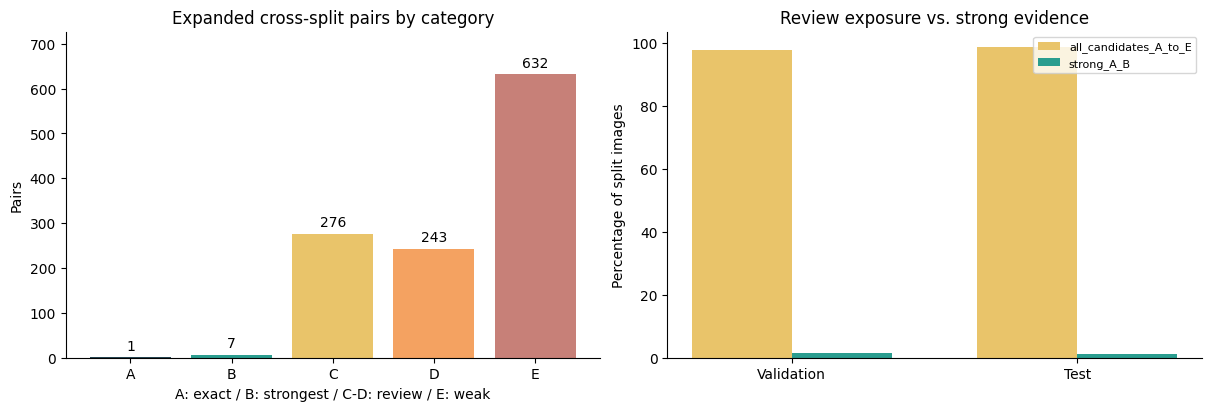

In [ ]:
original_pool = similarity.loc[similarity["is_audit_near_candidate"] | similarity["category"].eq("A")]
cross = similarity.loc[similarity["cross_split"]]
cross_original = original_pool.loc[original_pool["cross_split"]]
print("Expanded cross-split pairs by split combination and category:")
display(pd.crosstab(cross["split_combination"], cross["category"]).reindex(index=["train-val", "train-test", "val-test"], columns=list(CATEGORY_LABELS), fill_value=0))
print("Expanded cross-split pairs by disease class / cross-class comparison:")
display(pd.crosstab(cross["class_comparison"], cross["category"]).reindex(columns=list(CATEGORY_LABELS), fill_value=0))
print("Original audit + exact pool, separately:")
display(pd.crosstab(cross_original["split_combination"], cross_original["category"]).reindex(columns=list(CATEGORY_LABELS), fill_value=0))


def involved_images(pairs):
    return set(pairs["filepath_a"]) | set(pairs["filepath_b"])


exposure_rows = []
for scope, frame in (("original_audit_plus_exact", cross_original), ("expanded_evaluated_pool", cross)):
    for tier, categories in (("all_candidates_A_to_E", set(CATEGORY_LABELS)), ("strong_A_B", {"A", "B"}),
                             ("strong_or_probable_A_B_C", {"A", "B", "C"})):
        selected = frame.loc[frame["category"].isin(categories)]
        involved = involved_images(selected)
        for split in SPLITS:
            total = int(inventory["split"].eq(split).sum())
            count = sum(records[path]["split"] == split for path in involved)
            exposure_rows.append({"scope": scope, "tier": tier, "split": split, "unique_images": count,
                                  "split_total": total, "percentage": round(100 * count / total, 4) if total else 0})
exposure = pd.DataFrame(exposure_rows)
exposure.to_csv(REPORTS / "cross_split_exposure.csv", index=False)
display(exposure)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
counts = cross.groupby("category").size().reindex(list(CATEGORY_LABELS), fill_value=0)
bars = axes[0].bar(counts.index, counts.values, color=["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#c78078"])
axes[0].bar_label(bars, padding=3)
axes[0].set(title="Expanded cross-split pairs by category", ylabel="Pairs", xlabel="A: exact / B: strongest / C-D: review / E: weak")
axes[0].margins(y=0.15)
for i, tier in enumerate(("all_candidates_A_to_E", "strong_A_B")):
    values = exposure.loc[exposure["scope"].eq("expanded_evaluated_pool") & exposure["tier"].eq(tier)].set_index("split").reindex(["val", "test"])
    axes[1].bar(np.arange(2) + i * 0.35, values["percentage"], width=0.35, label=tier, color=["#e9c46a", "#2a9d8f"][i])
axes[1].set(xticks=np.arange(2) + 0.175, xticklabels=["Validation", "Test"], ylabel="Percentage of split images", title="Review exposure vs. strong evidence")
axes[1].legend(fontsize=8)
plt.show()


## 5. dHash-distance-zero investigation
Only original near-candidates are counted here; these exclude identical bytes. ?Compatible with re-encoding? is a hypothesis, not proof: even B could reflect a repeated capture. Adjacent captures, distinct specimens, normalization effects, and hash collisions require visual/provenance review.


In [ ]:
zero = similarity.loc[similarity["is_audit_near_candidate"] & similarity["existing_dhash_distance"].eq(0)].copy()
zero["interpretation"] = zero["category"].map({
    "B": "Extremely similar after normalization; compatible with re-encoding or near-identical capture. Verify originals.",
    "C": "Probable relationship; re-encoding versus adjacent capture unresolved.",
    "D": "Partial corroboration; inspect for distinct leaves, adjacent captures, or hash collision.",
    "E": "dHash equality lacks secondary support; possible collision, alignment effects, or distinct images.",
    "A": "Exact bytes (unexpected in original near pool)."})
zero.to_csv(REPORTS / "dhash_zero_review.csv", index=False)
print(f"Original dHash-zero pairs: {len(zero)}; cross-split: {int(zero['cross_split'].sum())}")
display(zero.groupby(["category", "category_label"]).agg(pairs=("category", "size"),
         median_phash_distance=("phash_distance", "median"), median_mae=("normalized_pixel_mae", "median"),
         median_color_intersection=("color_histogram_intersection", "median")))
display(zero[["filename_a", "split_a", "filename_b", "split_b", "category", "phash_distance", "normalized_pixel_mae", "color_histogram_intersection", "interpretation"]].head(12))


Original dHash-zero pairs: 37; cross-split: 37


,,pairs,median_phash_distance,median_mae,median_color_intersection
category,category_label,,,,
B,very-high-confidence visual duplicate,3,0.0,0.002637,0.982340
C,probable near duplicate,21,2.0,0.008900,0.969808
D,visually similar but uncertain,13,2.0,0.014906,0.926107


,filename_a,split_a,filename_b,split_b,category,phash_distance,normalized_pixel_mae,color_histogram_intersection,interpretation
45,2025_12_21_IMG (199).JPG,test,2025_12_21_IMG (198).JPG,train,D,2,0.010106,0.892253,Partial corroboration; inspect for distinct le...
56,2025_12_21_IMG (206).JPG,test,2025_12_21_IMG (207).JPG,train,D,4,0.015739,0.926107,Partial corroboration; inspect for distinct le...
58,2025_12_21_IMG (206).JPG,test,2025_12_21_IMG (205).JPG,val,C,2,0.008506,0.973145,Probable relationship; re-encoding versus adja...
70,2025_12_21_IMG (254).JPG,test,2025_12_21_IMG (253).JPG,val,D,4,0.017704,0.937988,Partial corroboration; inspect for distinct le...
91,2025_12_21_IMG (310).JPG,test,2025_12_21_IMG (1).JPG,train,C,2,0.009600,0.967855,Probable relationship; re-encoding versus adja...
98,2025_12_21_IMG (78).JPG,test,2025_12_21_IMG (77).JPG,train,C,6,0.023461,0.969808,Probable relationship; re-encoding versus adja...
99,2025_12_21_IMG (78).JPG,test,2025_12_21_IMG (80).JPG,train,C,2,0.014138,0.973389,Probable relationship; re-encoding versus adja...
130,2025_12_20_IMG (146).JPG,test,2025_12_21_IMG (208).JPG,train,D,0,0.036983,0.877604,Partial corroboration; inspect for distinct le...
131,2025_12_20_IMG (146).JPG,test,2025_12_20_IMG (145).JPG,val,C,0,0.008900,0.943115,Probable relationship; re-encoding versus adja...
153,2025_12_20_IMG (201).JPG,test,2025_12_20_IMG (200).JPG,train,D,4,0.012891,0.932210,Partial corroboration; inspect for distinct le...


## 6. Transparent connected components
An adjacency list and deterministic depth-first traversal join A/B edges only. Membership is transitive: chain endpoints need not be direct strong matches. Summaries retain observed edge counts, density, maximum strong-edge pHash/MAE, and mixed-class/split flags. Edge maxima do not describe every possible pair in a cluster. These are proposed groups subject to review.


In [ ]:
def connected_components(nodes, edges):
    adjacency = {node: set() for node in nodes}
    for first, second in edges:
        adjacency[first].add(second)
        adjacency[second].add(first)
    visited, groups = set(), []
    for start in sorted(adjacency):
        if start in visited: continue
        stack, members = [start], []
        visited.add(start)
        while stack:
            node = stack.pop()
            members.append(node)
            for neighbor in sorted(adjacency[node], reverse=True):
                if neighbor not in visited:
                    visited.add(neighbor)
                    stack.append(neighbor)
        groups.append(sorted(members))
    return groups


assert connected_components(["a", "b", "c", "d"], [("a", "b"), ("b", "c")]) == [["a", "b", "c"], ["d"]]
strong_edges = similarity.loc[similarity["category"].isin(STRONG_CATEGORIES)]
visual_components = connected_components(paths, strong_edges[["filepath_a", "filepath_b"]].itertuples(index=False, name=None))
visual_ids, visual_sizes, cluster_rows, cluster_summary_rows = {}, {}, [], []
strongest_incident = {}
for row in strong_edges.itertuples(index=False):
    for path in (row.filepath_a, row.filepath_b):
        strongest_incident[path] = min(strongest_incident.get(path, "Z"), row.category)
for index, members in enumerate(visual_components, start=1):
    group_id = f"cluster_{index:04d}"
    for path in members:
        visual_ids[path], visual_sizes[path] = group_id, len(members)
    if len(members) < 2: continue
    edges = strong_edges.loc[strong_edges["filepath_a"].isin(members) & strong_edges["filepath_b"].isin(members)]
    splits = sorted({records[p]["split"] for p in members}, key=SPLITS.index)
    classes = sorted({records[p]["class"] for p in members})
    cluster_summary_rows.append({"cluster_id": group_id, "cluster_size": len(members), "splits": "|".join(splits),
                                 "cross_split": len(splits) > 1, "classes": "|".join(classes),
                                 "cross_class": len(classes) > 1, "strong_edge_count": len(edges),
                                 "edge_density": 2 * len(edges) / (len(members) * (len(members) - 1)),
                                 "contains_B_edge": bool(edges["category"].eq("B").any()),
                                 "max_observed_edge_phash": int(edges["phash_distance"].max()),
                                 "max_observed_edge_mae": float(edges["normalized_pixel_mae"].max())})
    for path in members:
        category = strongest_incident[path]
        cluster_rows.append({"cluster_id": group_id, "filepath": path, **{k: records[path][k] for k in ("filename", "class", "split", "sha256")},
                             "strongest_similarity_category": category, "category_label": CATEGORY_LABELS[category],
                             "cluster_size": len(members), "review_status": "proposed grouping; verify visual relationships"})
clusters = pd.DataFrame(cluster_rows, columns=["cluster_id", "filepath", "filename", "class", "split", "sha256", "strongest_similarity_category", "category_label", "cluster_size", "review_status"])
cluster_summary = pd.DataFrame(cluster_summary_rows, columns=["cluster_id", "cluster_size", "splits", "cross_split", "classes", "cross_class", "strong_edge_count", "edge_density", "contains_B_edge", "max_observed_edge_phash", "max_observed_edge_mae"])
clusters.to_csv(REPORTS / "duplicate_clusters.csv", index=False)
cluster_summary.to_csv(REPORTS / "duplicate_cluster_summary.csv", index=False)
print(f"Non-singleton A/B groups: {len(cluster_summary)}; largest: {max(map(len, visual_components))}")
display(cluster_summary.sort_values(["cluster_size", "cluster_id"], ascending=[False, True]).head(20))


Non-singleton A/B groups: 14; largest: 4


,cluster_id,cluster_size,splits,cross_split,classes,cross_class,strong_edge_count,edge_density,contains_B_edge,max_observed_edge_phash,max_observed_edge_mae
3,cluster_0302,4,train|val|test,True,Healthy leaf,False,5,0.833333,True,2,0.014085
0,cluster_0274,2,val|test,True,Healthy leaf,False,1,1.000000,False,0,0.000000
1,cluster_0295,2,val|test,True,Healthy leaf,False,1,1.000000,True,0,0.002637
2,cluster_0296,2,val|test,True,Healthy leaf,False,1,1.000000,True,0,0.001879
4,cluster_0540,2,train,False,Black spot,False,1,1.000000,True,0,0.005381
5,cluster_0590,2,train,False,Black spot,False,1,1.000000,True,2,0.008791
6,cluster_0728,2,train,False,Black spot,False,1,1.000000,True,0,0.004026
7,cluster_0899,2,train,False,Citrus canker,False,1,1.000000,True,0,0.004767
8,cluster_0935,2,train,False,Citrus canker,False,1,1.000000,True,2,0.012941
9,cluster_1404,2,train,False,Greening,False,1,1.000000,True,2,0.007677


## 7. Sequential filenames and candidate capture sequences
The earlier six broad class/date groups are context, not confirmed capture identity. A sequence here requires neighboring numbers **and** A/B/C visual evidence, including within-split edges. Connected sequences may bridge different leaves; their IDs remain separate from visual IDs. Far-apart similar filenames are counted too: numbering alone can miss duplication.


In [ ]:
neighbor_edges = similarity.loc[similarity["is_filename_neighbor"]]
print("Secondary evidence for evaluated filename neighbors:")
display(neighbor_edges.groupby("category").size().reindex(list(CATEGORY_LABELS), fill_value=0).rename("neighbor_pairs").to_frame())
print("Number gaps among original near-candidates with the same class/date:")
gap_table = similarity.loc[similarity["is_audit_near_candidate"] & similarity["same_class_date"]].copy()
gap_table["number_gap_band"] = pd.cut(gap_table["filename_number_gap"], bins=[-1, 1, 5, 20, np.inf], labels=["0-1", "2-5", "6-20", ">20"])
display(pd.crosstab(gap_table["number_gap_band"], gap_table["category"]))
capture_edges = neighbor_edges.loc[neighbor_edges["same_class_date"] & neighbor_edges["category"].isin(CAPTURE_CATEGORIES)]
capture_components = [group for group in connected_components(paths, capture_edges[["filepath_a", "filepath_b"]].itertuples(index=False, name=None)) if len(group) > 1]
sequence_ids, sequence_rows = {}, []
prior_capture_ids = defaultdict(list)
for row in capture_input.itertuples(index=False):
    for path in json.loads(row.filepaths): prior_capture_ids[path].append(row.group_id)
for index, members in enumerate(capture_components, start=1):
    sequence_id = f"sequence_{index:04d}"
    edges = capture_edges.loc[capture_edges["filepath_a"].isin(members) & capture_edges["filepath_b"].isin(members)]
    for path in members:
        sequence_ids[path] = sequence_id
        sequence_rows.append({"capture_sequence_id": sequence_id, "filepath": path,
                              **{k: records[path][k] for k in ("filename", "class", "split")},
                              "date_token": filename_records[path]["date_token"],
                              "image_number": filename_records[path]["image_number"], "sequence_size": len(members),
                              "prior_broad_capture_ids": "|".join(sorted(prior_capture_ids[path])),
                              "supporting_edge_categories": "|".join(sorted(edges["category"].unique())),
                              "review_status": "candidate capture sequence requiring human verification"})
sequences = pd.DataFrame(sequence_rows, columns=["capture_sequence_id", "filepath", "filename", "class", "split", "date_token", "image_number", "sequence_size", "prior_broad_capture_ids", "supporting_edge_categories", "review_status"])
sequences.to_csv(REPORTS / "capture_sequence_candidates.csv", index=False)
print(f"Visually supported candidate capture sequences: {len(capture_components)}")
display(sequences.head(20))


Secondary evidence for evaluated filename neighbors:
Number gaps among original near-candidates with the same class/date:
Visually supported candidate capture sequences: 321


,neighbor_pairs
category,
A,3
B,13
C,438
D,333
E,1257


category,B,C,D,E
number_gap_band,,,,
0-1,5,186,99,1
2-5,2,71,65,1
6-20,0,2,7,4
>20,0,4,9,1


,capture_sequence_id,filepath,filename,class,split,date_token,image_number,sequence_size,prior_broad_capture_ids,supporting_edge_categories,review_status
0,sequence_0001,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (11).JPG,Algal leaf spot,test,2025-12-21,11,2,capture_0001,C,candidate capture sequence requiring human ver...
1,sequence_0001,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (10).JPG,Algal leaf spot,train,2025-12-21,10,2,capture_0001,C,candidate capture sequence requiring human ver...
2,sequence_0002,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (119).JPG,Algal leaf spot,test,2025-12-21,119,2,capture_0001,C,candidate capture sequence requiring human ver...
3,sequence_0002,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (120).JPG,Algal leaf spot,train,2025-12-21,120,2,capture_0001,C,candidate capture sequence requiring human ver...
4,sequence_0003,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (141).JPG,Algal leaf spot,test,2025-12-21,141,2,capture_0001,C,candidate capture sequence requiring human ver...
5,sequence_0003,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (142).JPG,Algal leaf spot,train,2025-12-21,142,2,capture_0001,C,candidate capture sequence requiring human ver...
6,sequence_0004,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (143).JPG,Algal leaf spot,test,2025-12-21,143,2,capture_0001,C,candidate capture sequence requiring human ver...
7,sequence_0004,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (144).JPG,Algal leaf spot,train,2025-12-21,144,2,capture_0001,C,candidate capture sequence requiring human ver...
8,sequence_0005,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (146).JPG,Algal leaf spot,test,2025-12-21,146,2,capture_0001,C,candidate capture sequence requiring human ver...
9,sequence_0005,dataset/val/Algal leaf spot/2025_12_21_IMG (14...,2025_12_21_IMG (145).JPG,Algal leaf spot,val,2025-12-21,145,2,capture_0001,C,candidate capture sequence requiring human ver...


## 8. Visual review: exact, strong, large, and uncertain groups
All exact cross-split groups are shown, paginated if necessary. Other sections are bounded. Strong groups show observed edge metrics. A reproducible random sample of uncertain C/D components is shown but **not merged into the manifest**. Contact sheets are review aids, not human approvals. PNGs and selection metadata are saved for independent review.


Saved 12 bounded review contact sheets.


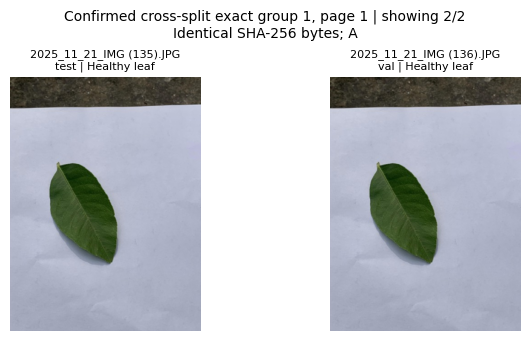

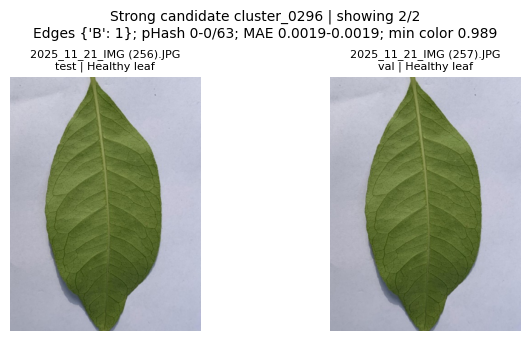

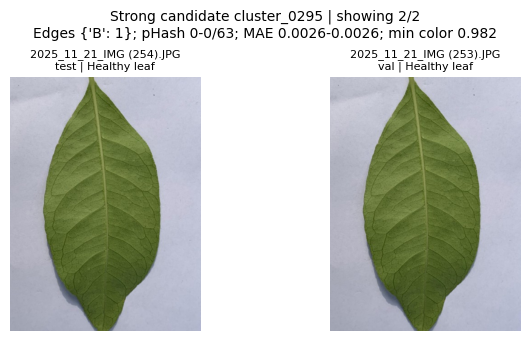

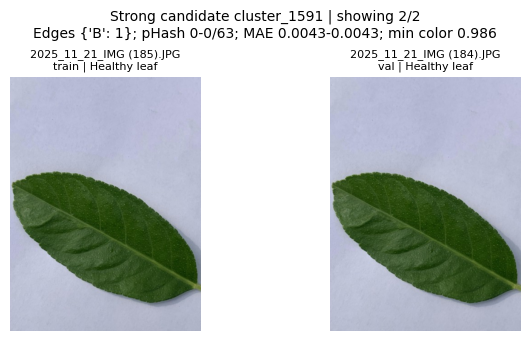

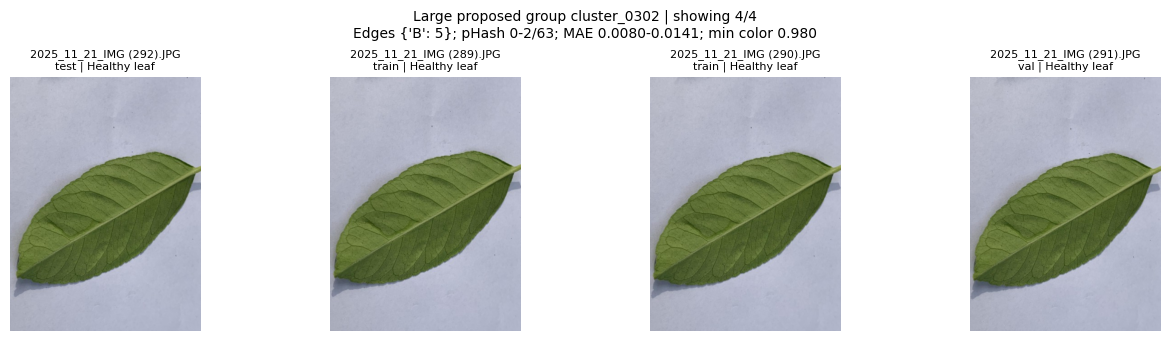

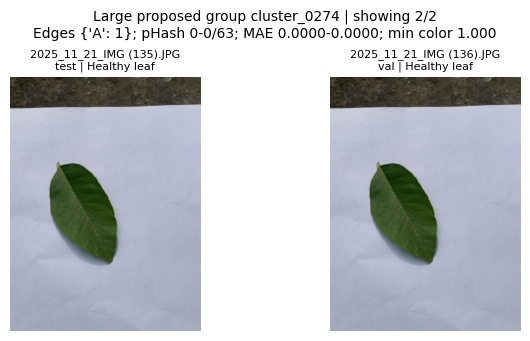

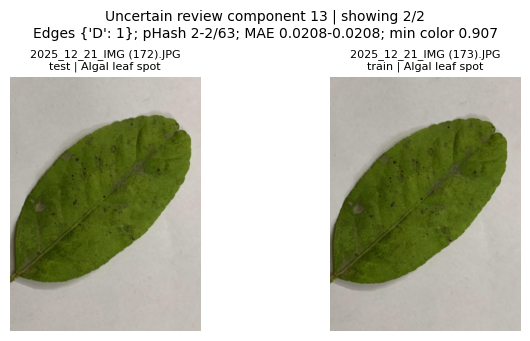

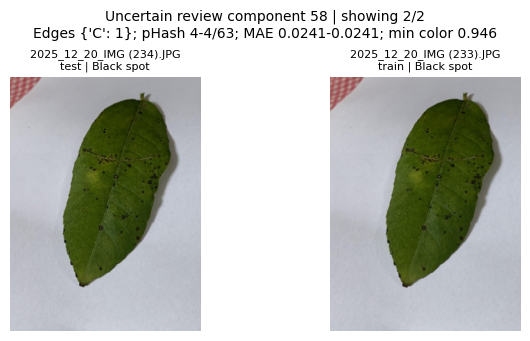

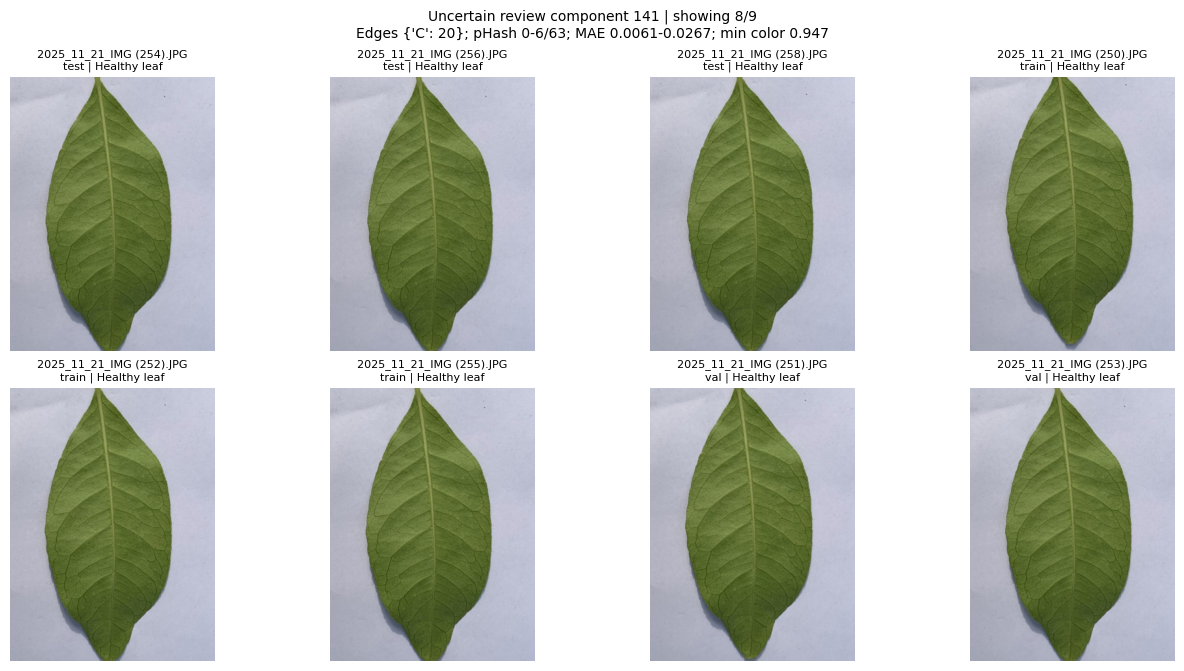

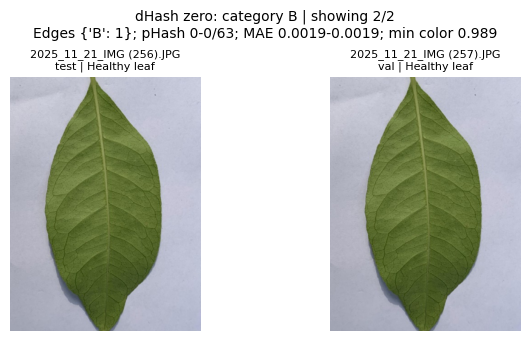

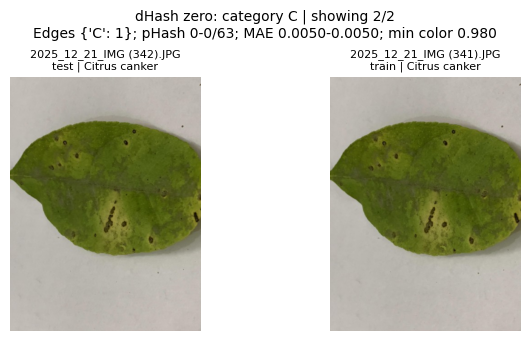

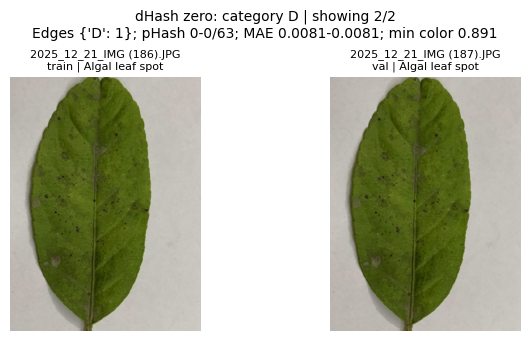

In [ ]:
SHEET_DIR = REPORTS / "duplicate_review_contact_sheets"
SHEET_DIR.mkdir(parents=True, exist_ok=True)
review_selections = []


def contact_sheet(members, title, slug, measurements, limit=MAX_IMAGES_PER_SHEET):
    shown = list(members)[:limit]
    columns = min(4, len(shown))
    rows = (len(shown) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(3.2 * columns, 3.3 * rows), squeeze=False, layout="constrained")
    for ax, path in zip(axes.ravel(), shown):
        with Image.open(dataset_path(path)) as image:
            preview = ImageOps.exif_transpose(image).convert("RGB")
            preview.thumbnail((420, 420))
            ax.imshow(preview)
        rec = records[path]
        ax.set_title(f"{rec['filename']}\n{rec['split']} | {rec['class']}", fontsize=8)
    for ax in axes.ravel(): ax.axis("off")
    fig.suptitle(f"{title} | showing {len(shown)}/{len(members)}\n{measurements}", fontsize=10)
    target = SHEET_DIR / f"{slug}.png"
    fig.savefig(target, dpi=100, bbox_inches="tight")
    review_selections.append({"sheet": target.relative_to(ROOT).as_posix(), "title": title,
                              "all_members": list(members), "shown_members": shown, "measurements": measurements})
    plt.show()


def edge_description(edges):
    counts = edges["category"].value_counts().sort_index().to_dict()
    return (f"Edges {counts}; pHash {edges['phash_distance'].min()}-{edges['phash_distance'].max()}/63; "
            f"MAE {edges['normalized_pixel_mae'].min():.4f}-{edges['normalized_pixel_mae'].max():.4f}; "
            f"min color {edges['color_histogram_intersection'].min():.3f}")


def component_edges(members, frame):
    return frame.loc[frame["filepath_a"].isin(members) & frame["filepath_b"].isin(members)]


cross_exact_groups = [group for group in exact_groups if len({records[p]["split"] for p in group}) > 1]
for index, members in enumerate(cross_exact_groups, start=1):
    for offset in range(0, len(members), MAX_IMAGES_PER_SHEET):
        page = members[offset:offset + MAX_IMAGES_PER_SHEET]
        contact_sheet(page, f"Confirmed cross-split exact group {index}, page {offset // MAX_IMAGES_PER_SHEET + 1}",
                      f"exact_{index:03d}_{offset:03d}", "Identical SHA-256 bytes; A")
strong_cross_groups = cluster_summary.loc[cluster_summary["cross_split"].eq(True) & cluster_summary["contains_B_edge"].eq(True)]
strong_cross_groups = strong_cross_groups.sort_values(["max_observed_edge_mae", "max_observed_edge_phash", "cluster_id"])
for row in strong_cross_groups.head(MAX_STRONG_SHEETS).itertuples(index=False):
    members = clusters.loc[clusters["cluster_id"].eq(row.cluster_id), "filepath"].tolist()
    contact_sheet(members, f"Strong candidate {row.cluster_id}", f"strong_{row.cluster_id}", edge_description(component_edges(members, strong_edges)))
for row in cluster_summary.sort_values(["cluster_size", "cluster_id"], ascending=[False, True]).head(MAX_LARGE_SHEETS).itertuples(index=False):
    members = clusters.loc[clusters["cluster_id"].eq(row.cluster_id), "filepath"].tolist()
    contact_sheet(members, f"Large proposed group {row.cluster_id}", f"large_{row.cluster_id}", edge_description(component_edges(members, strong_edges)))
uncertain_edges = cross.loc[cross["category"].isin(["C", "D"])]
uncertain_groups = [group for group in connected_components(involved_images(uncertain_edges), uncertain_edges[["filepath_a", "filepath_b"]].itertuples(index=False, name=None)) if len(group) > 1]
rng = random.Random(SEED)
selected_uncertain = sorted(rng.sample(range(len(uncertain_groups)), min(MAX_UNCERTAIN_SHEETS, len(uncertain_groups))))
for index in selected_uncertain:
    members = uncertain_groups[index]
    contact_sheet(members, f"Uncertain review component {index + 1}", f"uncertain_{index + 1:03d}", edge_description(component_edges(members, uncertain_edges)))
for category in ("B", "C", "D", "E"):
    selection = zero.loc[zero["category"].eq(category)].sort_values(["normalized_pixel_mae", "filepath_a", "filepath_b"])
    if len(selection):
        row = selection.iloc[0]
        contact_sheet([row["filepath_a"], row["filepath_b"]], f"dHash zero: category {category}", f"dhash_zero_{category}", edge_description(selection.iloc[:1]))
(REPORTS / "duplicate_review_contact_sheets.json").write_text(json.dumps(review_selections, indent=2) + "\n", encoding="utf-8")
print(f"Saved {len(review_selections)} bounded review contact sheets.")


### Observations from sampled contact-sheet review

The generated sheets were visually inspected during implementation; these observations are triage, not dataset-owner approvals or proof of shared specimen identity.

- **Healthy leaf, test IMG (256) / validation IMG (257), dHash-zero B:** highly similar outline and vein placement. Re-encoding and a nearly identical repeated capture remain competing explanations.
- **Citrus canker, test IMG (342) / train IMG (341), dHash-zero C:** closely matching outline and lesion layout despite missing the strict B rule. This deserves manual review alongside B pairs.
- **Algal leaf spot, train IMG (186) / validation IMG (187), dHash-zero D:** closely matching outlines and markings with tonal differences; the color threshold can push a visually close pair into uncertainty.
- **Algal leaf spot, test IMG (172) / train IMG (173), uncertain sample:** matching-looking lesion arrangements warrant review of the originals and capture records.

Consequently, A/B exposure is a strict evidence subset, **not an estimate of total leakage prevalence**. A/B-only grouping may leave related C/D images across splits. Review C/D and capture sequences before using the manifest to build a new split. Metrics and visual similarity alone do not establish that different files are re-encodings. No category or grouping was automatically upgraded based on these sample observations.


## 9. Proposed manifest ? every image exactly once
Every image gets a deterministic visual group ID, including singletons. A/B components share an ID; capture IDs remain separate. Review status is automated triage, not completed human review. Before a future split, review capture-sequence merging, cross-class conflicts, and transitive chains. IDs are stable for identical inputs/thresholds, not after dataset changes.


In [ ]:
uncertain_paths = involved_images(similarity.loc[similarity["category"].isin(["C", "D"])])
weak_paths = involved_images(similarity.loc[similarity["category"].eq("E")])
cluster_lookup = cluster_summary.set_index("cluster_id").to_dict("index")
manifest_rows = []
for path in paths:
    group_id = visual_ids[path]
    detail = cluster_lookup.get(group_id)
    flags = []
    if detail:
        flags.append("visual grouping requires human verification" if detail["contains_B_edge"] else "exact bytes confirmed; grouping review pending")
        if detail["cross_class"]: flags.append("cross-class label conflict review")
    if path in sequence_ids: flags.append("candidate capture sequence requires verification")
    if path in uncertain_paths: flags.append("uncertain visual relationship requires review")
    if not flags: flags.append("weak candidate only; singleton" if path in weak_paths else "no detected relationship; singleton")
    manifest_rows.append({"filepath": path, "filename": records[path]["filename"], "class": records[path]["class"],
                          "current_split": records[path]["split"], "sha256": records[path]["sha256"],
                          "visual_group_id": group_id, "visual_group_size": visual_sizes[path],
                          "capture_sequence_id": sequence_ids.get(path, ""), "review_status": "; ".join(flags)})
manifest = pd.DataFrame(manifest_rows)
assert manifest["filepath"].is_unique and set(manifest["filepath"]) == set(paths)
for row in strong_edges.itertuples(index=False):
    assert visual_ids[row.filepath_a] == visual_ids[row.filepath_b]
manifest.to_csv(REPORTS / "grouping_manifest.csv", index=False)
print(f"Manifest: {len(manifest):,} unique images; {manifest['visual_group_id'].nunique():,} proposed visual groups including singletons.")
display(manifest.head(12))


Manifest: 2,050 unique images; 2,034 proposed visual groups including singletons.


,filepath,filename,class,current_split,sha256,visual_group_id,visual_group_size,capture_sequence_id,review_status
0,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (101).JPG,Algal leaf spot,test,7c526bef19c885bdcacf9994c28050858f9af434bdb5db...,cluster_0001,1,,uncertain visual relationship requires review
1,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (11).JPG,Algal leaf spot,test,3889cb7e5b45e5efac5e5ca3e354be16c8e087017b5d38...,cluster_0002,1,sequence_0001,candidate capture sequence requires verificati...
2,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (110).JPG,Algal leaf spot,test,2278d11c6727ac669d2a668f358b36525150a25621ffdb...,cluster_0003,1,,uncertain visual relationship requires review
3,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (112).JPG,Algal leaf spot,test,219fcfaf90f39be0f3c45640ae3811ad94510b8c840707...,cluster_0004,1,,uncertain visual relationship requires review
4,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (113).JPG,Algal leaf spot,test,0a6d4528246a7f07ad83658ba2818c6f26e5ffb68d6d8d...,cluster_0005,1,,uncertain visual relationship requires review
5,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (119).JPG,Algal leaf spot,test,5f85c280d4ddfe68e5eae343584b3d6e8a94b6192b4180...,cluster_0006,1,sequence_0002,candidate capture sequence requires verificati...
6,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (135).JPG,Algal leaf spot,test,49fad4da16ea394ece9e4998fb33ea064c16e63b376e64...,cluster_0007,1,,uncertain visual relationship requires review
7,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (139).JPG,Algal leaf spot,test,3f261f6ec0a49ee866eedfa6563dd0d33eb5eb0c564156...,cluster_0008,1,,uncertain visual relationship requires review
8,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (141).JPG,Algal leaf spot,test,fa8c66ed153648b5f1e283b07c016110feca94f3c08f9a...,cluster_0009,1,sequence_0003,candidate capture sequence requires verificati...
9,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (143).JPG,Algal leaf spot,test,ac1c63e2f9b4f7d56eb787e413f05ca15e63bd971688e1...,cluster_0010,1,sequence_0004,candidate capture sequence requires verificati...


## 10. Safety verification and machine-generated summary
The before/after snapshot compares dataset membership, SHA-256, size, and modification timestamps, including non-image files. Input report hashes must remain unchanged. Summary exposure explicitly separates the original and expanded pools, and strong A/B evidence from all candidate categories.


In [ ]:
AFTER = dataset_snapshot()
assert BEFORE == AFTER, "Dataset changed during this run. Investigate before using outputs."
assert INPUT_HASHES == {name: digest_file(REPORTS / name) for name in INPUT_NAMES}, "An input report changed."


def exposure_counts(frame):
    involved = involved_images(frame)
    result = {"unique_images": len(involved)}
    for split in ("val", "test"):
        count = sum(records[p]["split"] == split for p in involved)
        total = int(inventory["split"].eq(split).sum())
        result[split] = {"images": count, "total": total, "percentage": round(100 * count / total, 4) if total else 0}
    return result


exposure_summary = {"original_audit_plus_exact": {"all_candidates": exposure_counts(cross_original),
                                                "strong_A_B": exposure_counts(cross_original.loc[cross_original["category"].isin(STRONG_CATEGORIES)])},
                    "expanded_evaluated_pool": {"all_candidates": exposure_counts(cross),
                                                 "strong_A_B": exposure_counts(cross.loc[cross["category"].isin(STRONG_CATEGORIES)])}}
expanded = exposure_summary["expanded_evaluated_pool"]
summary = {
    "schema_version": 1, "total_images": len(inventory),
    "exact_duplicate_groups": len(exact_groups), "cross_split_exact_duplicate_groups": len(cross_exact_groups),
    "near_duplicate_candidates": len(near_input), "expanded_evaluated_pairs": len(similarity),
    "dhash_zero_candidate_pairs": len(zero), "dhash_zero_cross_split_pairs": int(zero["cross_split"].sum()),
    "dhash_zero_secondary_category_counts": {str(k): int(v) for k, v in zero["category"].value_counts().sort_index().items()},
    "high_confidence_visual_duplicate_groups": int(cluster_summary["contains_B_edge"].eq(True).sum()),
    "strong_A_B_groups": len(cluster_summary),
    "cross_split_strong_A_B_groups": int(cluster_summary["cross_split"].eq(True).sum()),
    "cross_class_strong_groups": int(cluster_summary["cross_class"].eq(True).sum()),
    "unique_images_in_cross_split_similarity": expanded["all_candidates"]["unique_images"],
    "validation_images_potentially_affected": expanded["all_candidates"]["val"],
    "test_images_potentially_affected": expanded["all_candidates"]["test"],
    "exposure_by_scope_and_evidence": exposure_summary,
    "original_near_category_counts": {str(k): int(v) for k, v in similarity.loc[similarity["is_audit_near_candidate"], "category"].value_counts().sort_index().items()},
    "expanded_cross_split_category_counts": {str(k): int(v) for k, v in cross["category"].value_counts().sort_index().items()},
    "expanded_cross_split_pairs_by_split": {str(k): int(v) for k, v in cross["split_combination"].value_counts().sort_index().items()},
    "largest_cluster_size": max(map(len, visual_components)), "candidate_capture_sequences": len(capture_components),
    "capture_sequence_images": len(sequence_ids), "visual_groups_including_singletons": int(manifest["visual_group_id"].nunique()),
    "contact_sheets": len(review_selections), "seed": SEED, "thresholds": THRESHOLDS,
    "phash_bits": 63, "sequence_max_gap": SEQUENCE_MAX_GAP,
    "input_report_sha256": INPUT_HASHES, "dataset_membership_content_and_mtime_unchanged": BEFORE == AFTER,
    "environment": {"python": platform.python_version(), **versions},
    "interpretation": "A confirms bytes. B-D and capture sequences require human verification. Exposure is not measured accuracy inflation. No images or splits changed; no training.",
    "scope_limitations": "Original dHash candidates plus exact matches and same-class/date filename neighbors. No exhaustive secondary search or specimen verification. A/B chains may connect endpoints without direct strong evidence."
}
(REPORTS / "duplicate_review_summary.json").write_text(json.dumps(summary, indent=2) + "\n", encoding="utf-8")
display(pd.Series({key: summary[key] for key in ["total_images", "exact_duplicate_groups", "cross_split_exact_duplicate_groups", "near_duplicate_candidates", "dhash_zero_candidate_pairs", "high_confidence_visual_duplicate_groups", "cross_split_strong_A_B_groups", "largest_cluster_size", "candidate_capture_sequences"]}, name="count").to_frame())
print("Verified: no dataset file deleted, moved, renamed, or modified during execution.")


Verified: no dataset file deleted, moved, renamed, or modified during execution.


,count
total_images,2050
exact_duplicate_groups,3
cross_split_exact_duplicate_groups,1
near_duplicate_candidates,476
dhash_zero_candidate_pairs,37
high_confidence_visual_duplicate_groups,11
cross_split_strong_A_B_groups,5
largest_cluster_size,4
candidate_capture_sequences,321


## 11. Implications for model evaluation
The conclusion below is generated from measured results. Candidate exposure cannot establish the magnitude of an accuracy change. Historical 97.44% test accuracy is not reproduced here.


In [ ]:
strong_exposure = expanded["strong_A_B"]
if len(cross_exact_groups) or summary["cross_split_strong_A_B_groups"]:
    risk_statement = "An unconstrained image-level random split appears unsafe for future evaluation: confirmed byte matches and/or strongly corroborated visual relationships already cross boundaries."
else:
    risk_statement = "The comparison pool did not establish strong cross-split relationships. This does not prove independence: search coverage is bounded and specimen identities are unknown."
conclusion = f"""
**Measured evidence.** {len(cross_exact_groups)} exact-byte groups cross splits. The expanded pool contains {summary['cross_split_strong_A_B_groups']} proposed A/B groups crossing splits. Strong pair evidence involves {strong_exposure['val']['images']}/{strong_exposure['val']['total']} validation images ({strong_exposure['val']['percentage']:.2f}%) and {strong_exposure['test']['images']}/{strong_exposure['test']['total']} test images ({strong_exposure['test']['percentage']:.2f}%). These quantities overlap and should not be added.

**Split design.** {risk_statement} Related images on both sides could inflate performance. A reviewed grouped split may be needed to keep related images together. No split is created here.

**Remaining uncertainty.** B-D thresholds are heuristic; resizing can suppress detail; graph chains can join endpoints without direct strong evidence. The {len(capture_components)} candidate capture sequences need acquisition records or human review to establish shared specimens. dHash-zero equality alone does not establish duplication or re-encoding. Contact sheets are review aids, not human approvals.

**Historical accuracy.** These are independence risks, not a quantified accuracy correction. This does not establish that the historical score is wholly invalid. Assess any effect after reviewing groups, defining an independent split, and conducting a separately authorized evaluation.
"""
display(Markdown(conclusion))



**Measured evidence.** 1 exact-byte groups cross splits. The expanded pool contains 5 proposed A/B groups crossing splits. Strong pair evidence involves 5/305 validation images (1.64%) and 4/312 test images (1.28%). These quantities overlap and should not be added.

**Split design.** An unconstrained image-level random split appears unsafe for future evaluation: confirmed byte matches and/or strongly corroborated visual relationships already cross boundaries. Related images on both sides could inflate performance. A reviewed grouped split may be needed to keep related images together. No split is created here.

**Remaining uncertainty.** B-D thresholds are heuristic; resizing can suppress detail; graph chains can join endpoints without direct strong evidence. The 321 candidate capture sequences need acquisition records or human review to establish shared specimens. dHash-zero equality alone does not establish duplication or re-encoding. Contact sheets are review aids, not human approvals.

**Historical accuracy.** These are independence risks, not a quantified accuracy correction. This does not establish that the historical score is wholly invalid. Assess any effect after reviewing groups, defining an independent split, and conducting a separately authorized evaluation.
